In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

'0.1.2'

In [3]:
# Load data
adata_raw=sc.read('../Garfield_test/data/panc8.h5ad')
adata_raw

AnnData object with n_obs × n_vars = 14890 × 34363
    obs: 'ClusterID', 'ClusterName', 'batch', 'celltype', 'nCount_RNA'
    var: 'Selected', 'vst_mean', 'vst_variable', 'vst_variance', 'vst_variance_expected', 'vst_variance_standardized'
    obsm: 'pca_cell_embeddings', 'umap_cell_embeddings'
    varm: 'pca_feature_loadings'
    layers: 'counts', 'norm_data', 'scale_data'

In [4]:
# Inspect the batches contained in the dataset.
adata_raw.obs.batch.value_counts()

batch
indrop        8569
smartseq2     2394
celseq2       2285
celseq        1004
fluidigmc1     638
Name: count, dtype: int64

In [ ]:
# The data processing procedure is according to the scanpy tutorial
sc.pp.filter_cells(adata_raw, min_genes=600)
sc.pp.filter_genes(adata_raw, min_cells=3)
adata_raw = adata_raw[:, [gene for gene in adata_raw.var_names if not str(gene).startswith(tuple(['ERCC', 'MT-', 'mt-']))]]
sc.pp.normalize_total(adata_raw, target_sum=1e4)
sc.pp.log1p(adata_raw)
sc.pp.highly_variable_genes(adata_raw, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata_raw.raw = adata_raw
adata_raw = adata_raw[:, adata_raw.var.highly_variable]
sc.pp.scale(adata_raw, max_value=10)
sc.pp.pca(adata_raw)
sc.pp.neighbors(adata_raw)
sc.tl.umap(adata_raw)

/home/zhouweige/anaconda3/envs/Garfield/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/zhouweige/anaconda3/envs/Garfield/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


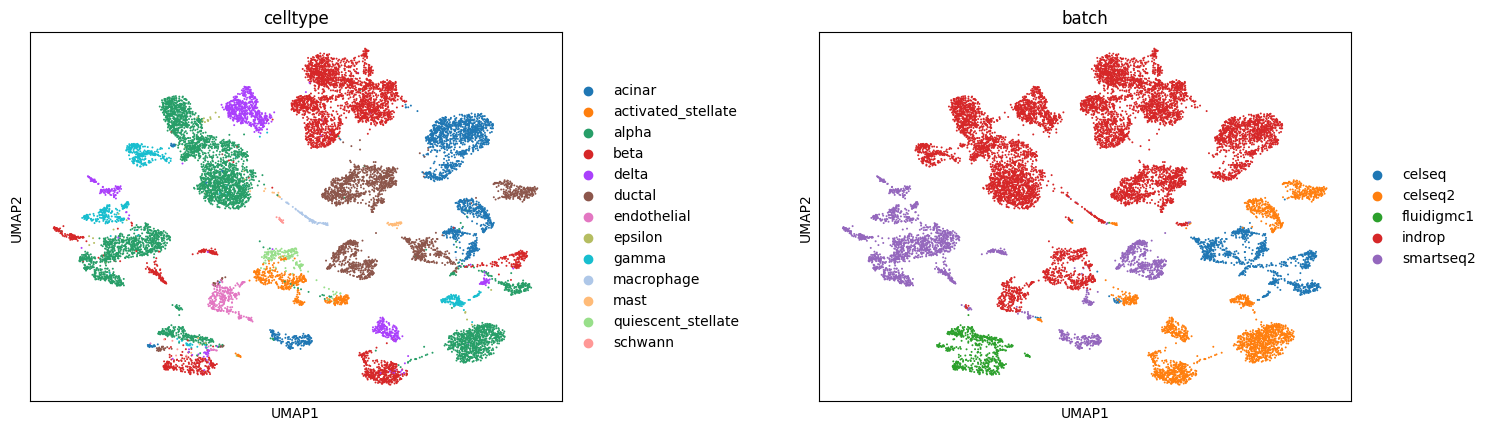

In [6]:
# We observe a batch effect.
sc.pl.umap(adata_raw,color=['celltype','batch'], wspace=0.35, legend_fontsize=10)

## split all_adata into reference dataset and query dataset

In [5]:
adata_raw=sc.read('../Garfield_test/data/panc8.h5ad')
adata_ref = adata_raw[~adata_raw.obs['batch'].isin(['celseq', 'celseq2']),:]
adata_ref

View of AnnData object with n_obs × n_vars = 11601 × 34363
    obs: 'ClusterID', 'ClusterName', 'batch', 'celltype', 'nCount_RNA'
    var: 'Selected', 'vst_mean', 'vst_variable', 'vst_variance', 'vst_variance_expected', 'vst_variance_standardized'
    obsm: 'pca_cell_embeddings', 'umap_cell_embeddings'
    varm: 'pca_feature_loadings'
    layers: 'counts', 'norm_data', 'scale_data'

In [6]:
# Inspect the batches contained in the dataset.
adata_ref.obs.batch.value_counts()

batch
indrop        8569
smartseq2     2394
fluidigmc1     638
Name: count, dtype: int64

In [7]:
adata_query = adata_raw[adata_raw.obs['batch'].isin(['celseq', 'celseq2']),:]
adata_query

View of AnnData object with n_obs × n_vars = 3289 × 34363
    obs: 'ClusterID', 'ClusterName', 'batch', 'celltype', 'nCount_RNA'
    var: 'Selected', 'vst_mean', 'vst_variable', 'vst_variance', 'vst_variance_expected', 'vst_variance_standardized'
    obsm: 'pca_cell_embeddings', 'umap_cell_embeddings'
    varm: 'pca_feature_loadings'
    layers: 'counts', 'norm_data', 'scale_data'

In [8]:
# Inspect the batches contained in the dataset.
adata_query.obs.batch.value_counts()

batch
celseq2    2285
celseq     1004
Name: count, dtype: int64

## Integrating reference data using Garfield

In [9]:
# set workdir
workdir = 'result_panc_ref_with_Garfield'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    data_dir=workdir,  # STR     Location of the dataset to be used.         Default is `data`.
    project_name='panc_ref',  # STR     Name of the dataset to be used.             Default is `name`.
    adata_list=adata_ref,  # STR     adata object of single-cell dataset.         Default is `adata`.
    profile='RNA',   # STR     Type of single-cell dataset.                  Default is `RNA`.
    sample_col='batch',  # STR     Column name of sample in adata.obs.       Default is `batch`.

    ## Preprocessing options
    rna_n_top_features=2000,
    metric='euclidean',  # STR     Metric for clustering.                   Default is `euclidean`.

    ## Model options
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    svd_q=5,  # default=5, type=int, help='rank'
    cluster_num=20, # default=20, type=int, help='number of clusters for contrastive loss'
    test_split=0.2,
    val_split=0.2,
    used_edge_weight=False,
    used_recon_exp=True,
    used_DSBN=False,
    used_mmd=True,
    loader_type='graphsaint',
    batch_size=256,  # INT   batch size of model training
    num_neighbors=[5, 5],
    epochs=50,  # INT       Number of epochs.                        Default is 100.
    mmd_temperature=0.2,  ## mmd regu
    instance_temperature=1.0,
    cluster_temperature=0.5,
    monitor_only_val_losses=False,
    learning_rate=0.001
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: result_panc_ref_with_Garfield


In [10]:
## start training on panc_ref dataset
from Garfield.model import GarfieldTrainer
trainer = GarfieldTrainer(dict_config)
trainer.fit()


Preparing dataset...

Data files exist, loading...
Finished loading.

Model training.

 |████----------------| 20.0%  - epoch_total_loss: 451.6129760742 - epoch_vgae_loss: 5.5029332638 - epoch_instance_loss: 6.8633923531 - epoch_cluster_loss: 3.6479520798 - epoch_recon_loss: 231.5275726318 - epoch_mmd_loss: 990.3658752441 - epoch_regu_loss: 5997.9257812500 - val_total_loss: 465.4926757812 - val_vgae_loss: 5.0359992981 - val_instance_loss: 6.8325948715 - val_cluster_loss: 3.6451239586 - val_recon_loss: 211.9099121094 - val_mmd_loss: 1160.4042968750 - val_regu_loss: 5988.1938476562 - test_roc_auc: 0.8028343926 - test_precision: 0.7714915721 - test_accuracy: 0.5000000000 - test_f1_score: 0.5000000000000

EarlyStopping: run 10 epoch


In [11]:
# calculate training time
trainer.training_time/60

3.377526307106018

In [12]:
## After pretraining the model can be saved for later use
ref_path = 'reference_model/'
trainer.save(ref_path, overwrite=True)

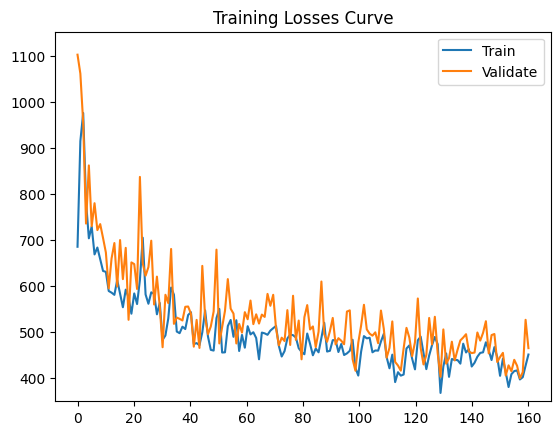

<Figure size 640x480 with 0 Axes>

In [13]:
## plot loss curve
trainer.plot_losses_curve()

In [14]:
# obtain latent representation
import scanpy as sc
adata_final = trainer.get_latent_representation()
adata_final

eval mode
Perform get_latent for cells via mini-batch mode


AnnData object with n_obs × n_vars = 11601 × 2000
    obs: 'ClusterID', 'ClusterName', 'batch', 'celltype', 'nCount_RNA', 'n_genes'
    var: 'Selected', 'vst_mean', 'vst_variable', 'vst_variance', 'vst_variance_expected', 'vst_variance_standardized', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'pca_cell_embeddings', 'umap_cell_embeddings', 'X_pca', 'X_gf'
    varm: 'pca_feature_loadings', 'PCs'
    layers: 'counts', 'norm_data', 'scale_data'
    obsp: 'distances', 'connectivities'

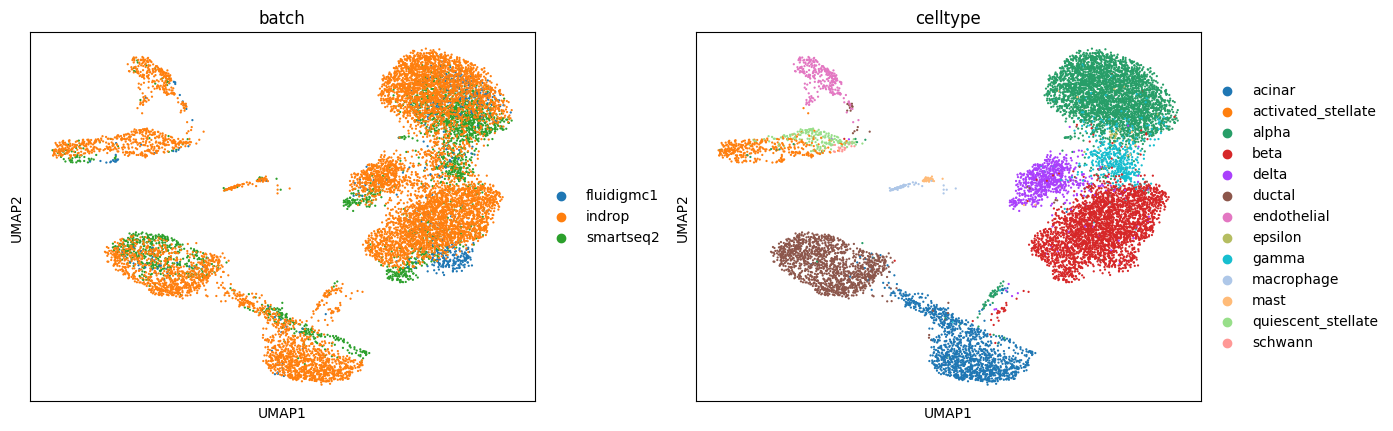

In [15]:
# plot UMAP
sc.tl.umap(adata_final)
sc.pl.umap(adata_final, color=['batch', 'celltype'], wspace=0.20, edges=False, save='_panc_ref_garfield.pdf')

## Perform surgery on reference model and fine-tune on query dataset

In [16]:
new_model = trainer.load_query_data(adata=adata_query, reference_model=ref_path, project_name='panc_query')
new_model.fit()


Preparing dataset...

Data files exist, loading...
Finished loading.

Model training.

 |████----------------| 24.0%  - epoch_total_loss: 2216.9519042969 - epoch_vgae_loss: 33.8831119537 - epoch_instance_loss: 6.8701555729 - epoch_cluster_loss: 3.6724319458 - epoch_recon_loss: 896.7763366699 - epoch_mmd_loss: 6340.5350341797 - epoch_regu_loss: 7642.7763671875 - val_total_loss: 2501.4379882812 - val_vgae_loss: 34.9268226624 - val_instance_loss: 6.8309049606 - val_cluster_loss: 3.7087109089 - val_recon_loss: 860.2140502930 - val_mmd_loss: 7940.5888671875 - val_regu_loss: 7639.7451171875 - test_roc_auc: 0.5046728972 - test_precision: 0.5023474178 - test_accuracy: 0.5046728972 - test_f1_score: 0.504672897204

EarlyStopping: run 12 epoch


In [17]:
# calculate training time
new_model.training_time/60

4.189430622259776

In [18]:
# obtain latent representation
import scanpy as sc
adata_concat = new_model.get_latent_representation()
adata_concat

eval mode
Perform get_latent for cells via mini-batch mode


AnnData object with n_obs × n_vars = 14890 × 2000
    obs: 'ClusterID', 'ClusterName', 'batch', 'celltype', 'nCount_RNA', 'projection', 'n_genes'
    var: 'n_cells'
    uns: 'log1p', 'pca', 'neighbors'
    obsm: 'pca_cell_embeddings', 'umap_cell_embeddings', 'X_pca', 'X_gf'
    varm: 'PCs'
    layers: 'counts', 'norm_data', 'scale_data'
    obsp: 'distances', 'connectivities'

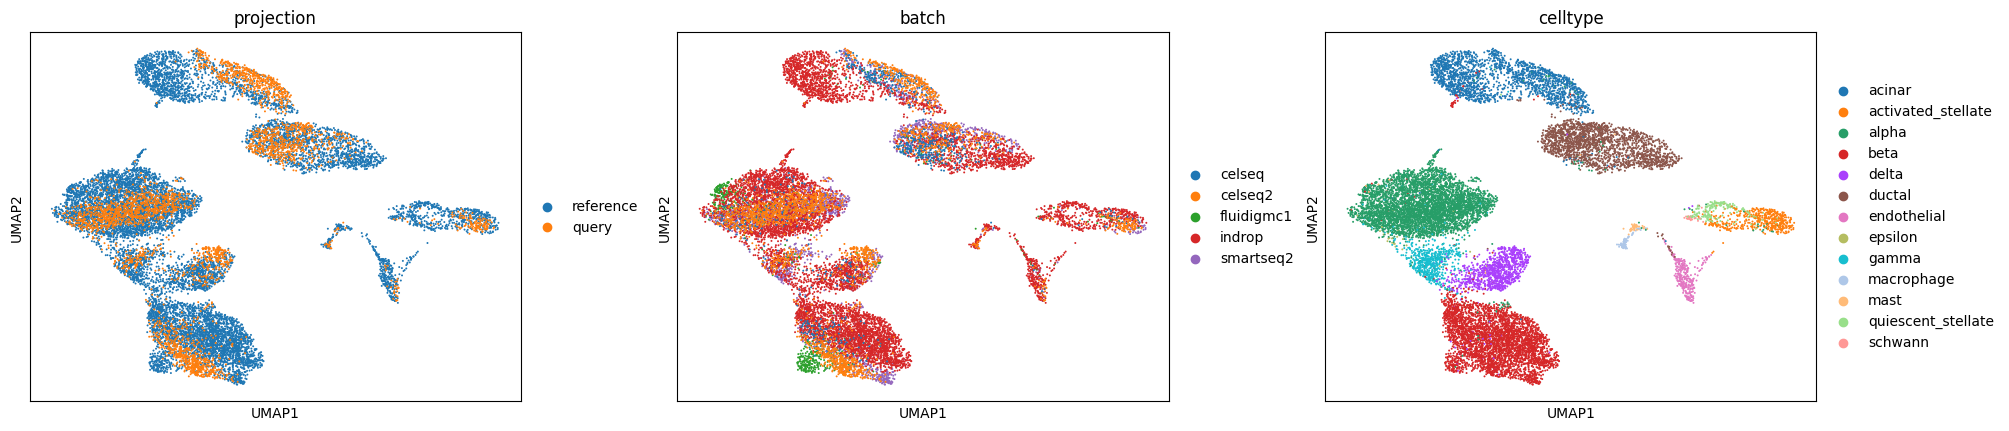

In [20]:
# plot UMAP
sc.tl.umap(adata_concat)
sc.pl.umap(adata_concat, color=['projection', 'batch', 'celltype'], wspace=0.20, edges=False, save='_panc_concat_garfield.pdf')

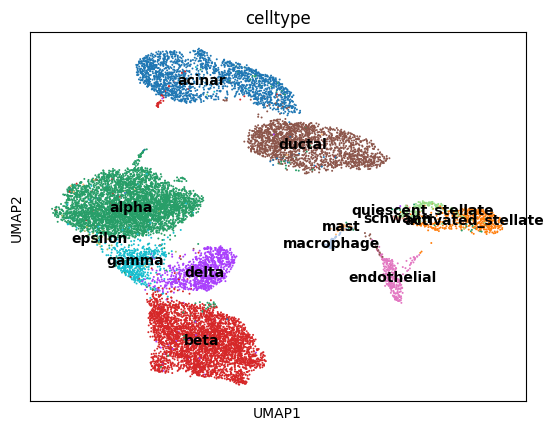

In [21]:
sc.pl.umap(adata_concat, color=['celltype'], wspace=0.20, edges=False, legend_loc='on data')

## Label transfer

In [22]:
adata_ref = adata_concat[adata_concat.obs['projection'] == 'reference', :]
adata_query = adata_concat[adata_concat.obs['projection'] == 'query', :]
adata_query

View of AnnData object with n_obs × n_vars = 3289 × 2000
    obs: 'ClusterID', 'ClusterName', 'batch', 'celltype', 'nCount_RNA', 'projection', 'n_genes'
    var: 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'projection_colors', 'batch_colors', 'celltype_colors'
    obsm: 'pca_cell_embeddings', 'umap_cell_embeddings', 'X_pca', 'X_gf', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'norm_data', 'scale_data'
    obsp: 'distances', 'connectivities'

In [23]:
adata_query=new_model.label_transfer(ref_adata=adata_ref,
                                     ref_adata_emb='X_gf',
                                     query_adata=adata_query,
                                     query_adata_emb='X_gf',
                                     ref_adata_obs=adata_ref.obs,
                                     label_keys='celltype')
adata_query

Weighted KNN with n_neighbors = 50 ... Label transfer finished!


AnnData object with n_obs × n_vars = 3289 × 2000
    obs: 'ClusterID', 'ClusterName', 'batch', 'celltype', 'nCount_RNA', 'projection', 'n_genes', 'transferred_celltype_unfiltered', 'transferred_celltype_uncert'
    var: 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'projection_colors', 'batch_colors', 'celltype_colors'
    obsm: 'pca_cell_embeddings', 'umap_cell_embeddings', 'X_pca', 'X_gf', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'norm_data', 'scale_data'
    obsp: 'distances', 'connectivities'

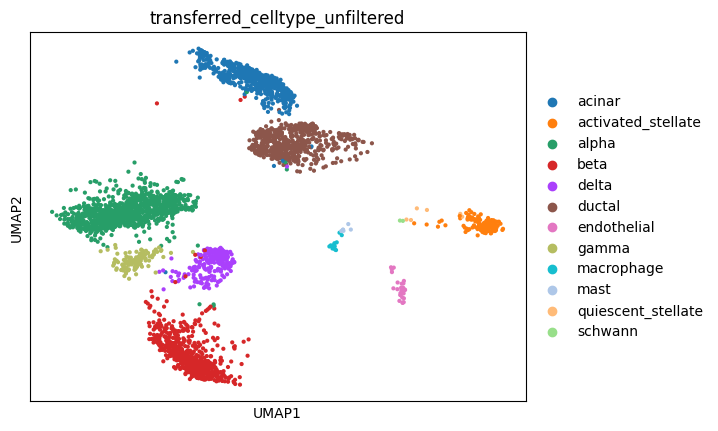

In [24]:
## predicted label
sc.pl.umap(adata_query,color=['transferred_celltype_unfiltered'])

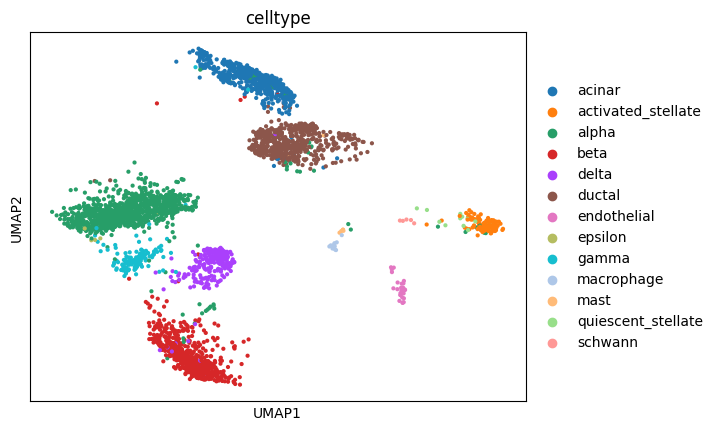

In [25]:
## real label
sc.pl.umap(adata_query,color=['celltype'])

In [26]:
import pandas as pd
pd.crosstab(adata_query.obs.celltype, adata_query.obs.transferred_celltype_unfiltered)

transferred_celltype_unfiltered,acinar,activated_stellate,alpha,beta,delta,ductal,endothelial,gamma,macrophage,mast,quiescent_stellate,schwann
celltype,,,,,,,,,,,,
acinar,495,0,1,0,0,7,0,0,0,0,0,0
activated_stellate,0,109,0,0,0,0,0,0,0,0,0,0
alpha,17,7,1007,12,1,9,0,2,0,2,0,0
beta,1,0,0,602,2,0,0,1,0,0,0,0
delta,0,0,0,15,235,1,0,2,0,0,0,0
ductal,8,0,3,0,0,550,0,0,0,0,0,0
endothelial,0,0,0,0,0,0,26,0,0,0,0,0
epsilon,0,0,5,0,0,0,0,0,0,0,0,0
gamma,2,0,11,0,3,0,0,112,0,0,0,0


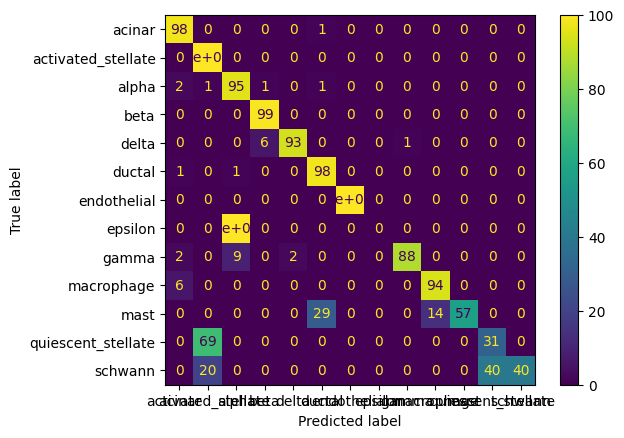

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

cm = confusion_matrix(adata_query.obs.celltype, adata_query.obs.transferred_celltype_unfiltered)
ConfusionMatrixDisplay(
    confusion_matrix=np.round((cm.T/np.sum(cm, axis=1)).T*100),
    display_labels=np.unique(adata_query.obs.celltype)
).plot()